# Focus sui Vettori di Embeddings

### Analisi semplificata della similarità tra frasi nello Spazio Latente dei modelli di linguaggio

In [2]:
import numpy as np  # pip install numpy
from sklearn.metrics.pairwise import cosine_similarity  # pip install scikit-learn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt  # pip install matplotlib
from transformers import BertTokenizer, BertModel  # pip install transformers
import torch  # https://pytorch.org/get-started/locally/ pip install torch torchvision

## BERT
#### (Bidirectional Encoder Representations from Transformers)

BERT è un modello di linguaggio basato su una rete di Transformer sviluppato da Google, progettato per comprendere il contesto di una parola in un testo analizzando simultaneamente le parole a sinistra e a destra di essa (approccio bidirezionale).    
Addestrato su grandi quantità di testo non supervisionato, BERT è particolarmente efficace nei compiti di elaborazione del linguaggio naturale come il **riconoscimento di entità**, l'**analisi del sentiment** e le **risposte a domande**.    
Il suo addestramento prevede due task principali: 
* **masked language modeling** (dove alcune parole vengono nascoste e il modello deve predirle)
* **next sentence prediction** (dove il modello impara le relazioni tra frasi consecutive).

In [3]:
# Funzione per creare vettori di embeddings usando BERT
# esistono due versioni principali di BERT:
# `bert-base`: 110 milioni di parametri
# `bert-large`: 340 milioni di parametri (più grande e più potente, ma anche più costoso in termini di calcolo)
# `uncased`: il modello non fa distinzione tra lettere maiuscole e minuscole (prima dell'addestramento, tutto 
# il testo viene convertito in minuscolo). Esiste anche una versione `cased`, che invece preserva le maiuscole
def create_embeddings(sentences):
    # carichiamo il tokenizer e un modello pre-addestrato BERT
    # da https://huggingface.co/ArchitRastogi/bert-base-italian-embeddings
    tokenizer = BertTokenizer.from_pretrained('ArchitRastogi/bert-base-italian-embeddings')  # ~450MB
    model = BertModel.from_pretrained('ArchitRastogi/bert-base-italian-embeddings')
    
    # impostiamo il modello in modalità di valutazione (inferenza)
    model.eval()

    # tokenizzazione delle frasi e creazione dei tensori per BERT
    with torch.no_grad():  # Disabilita il calcolo del gradiente per velocizzare
        encoded_inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')
        outputs = model(**encoded_inputs)
    
    # prendiamo gli embeddings dalla rappresentazione nascosta di BERT (ultimo layer)
    # outputs.last_hidden_state ha forma (batch_size, sequence_length, hidden_size)
    # applichiamo la media su sequence_length per ottenere un singolo vettore per ogni frase
    sentence_embeddings = torch.mean(outputs.last_hidden_state, dim=1)

    # convertiamo i tensori in numpy array per utilizzarli successivamente
    return sentence_embeddings.numpy()

In [4]:
def plot_embeddings(embeddings, sentences, elev=20, azim=45):
    # applicazione della PCA per ridurre la dimensionalità 
    # dei vettori di embeddings a 3
    pca = PCA(n_components=3)
    embeddings_3d = pca.fit_transform(embeddings)

    # creazione di due subplot per la visualizzazione 3D
    fig = plt.figure(figsize=(15, 6))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2])
    for i, sentence in enumerate(sentences):
        ax1.text(embeddings_3d[i, 0], embeddings_3d[i, 1], embeddings_3d[i, 2], sentence)
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    
    plt.title('Visualizzazione degli Embeddings (PCA)')
    
    # rotazione della vista
    ax1.view_init(elev=elev, azim=azim)

    # altro subplot 3D
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2])
    for i, sentence in enumerate(sentences):
        ax2.text(embeddings_3d[i, 0], embeddings_3d[i, 1], embeddings_3d[i, 2], sentence)
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    
    ax2.view_init(elev=elev * 3, azim=azim * 3)

    plt.tight_layout()
    plt.show()

Creazione degli embeddings...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Visualizzazione degli embeddings...


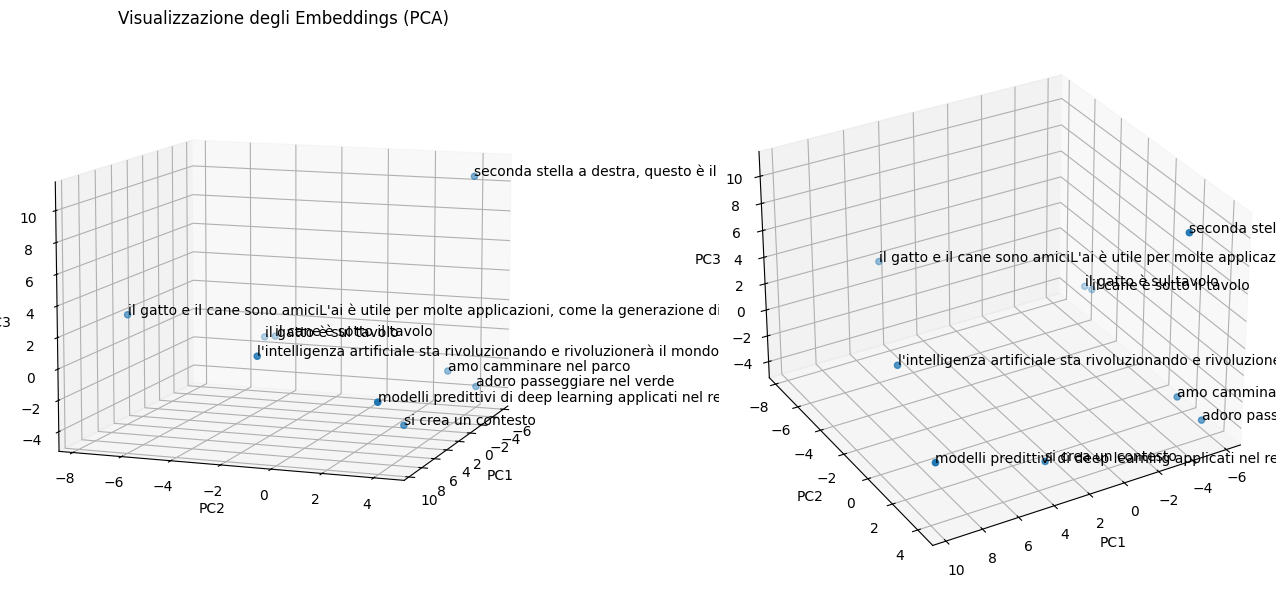

In [5]:
# Esempio di utilizzo

# definizione delle frasi di esempio
sentences = [
    "amo camminare nel parco",
    "adoro passeggiare nel verde",
    "l'intelligenza artificiale sta rivoluzionando e rivoluzionerà il mondo",
    "modelli predittivi di deep learning applicati nel reinforcement learning",
    "seconda stella a destra, questo è il cammino, e poi dritto fino al mattino",
    "si crea un contesto",
    "il gatto è sul tavolo",
    "il cane è sotto il tavolo",
    "il gatto e il cane sono amici"
    "L'ai è utile per molte applicazioni, come la generazione di testo, la traduzione automatica e il riconoscimento vocale"
]


print("Creazione degli embeddings...")
embeddings = create_embeddings(sentences)

print("\nVisualizzazione degli embeddings...")
plot_embeddings(embeddings, sentences, elev=10, azim=20)

In [ ]:
# analisi delle similitudini

def find_most_similar(embeddings, sentences, i):
    # Estrai l'embedding della frase i-esima
    target_embedding = embeddings[i]
    
    # Calcola la similarità del coseno tra l'embedding target e tutti gli altri embeddings
    # n.b. `target_embedding` ha dimensione (1xd) mentre `embeddings` ha dimensione (nxd)
    #      quindi avremo un output (1xn) con n numero di vettori in embeddings
    #      per questo motivo prendiamo il primo (unico) elemento di cosine_similarity
    similarities = cosine_similarity([target_embedding], embeddings)[0]
    
    # Trova l'indice della frase più simile
    most_similar_idx = np.argsort(similarities)[-2]  # prendiamo il secondo più alto
                                                     # il primo è la frase stessa
    
    # Restituisci la frase più simile e il valore della similarità
    most_similar_sentence = sentences[most_similar_idx]
    similarity_value = similarities[most_similar_idx]
    
    return most_similar_sentence, similarity_value

print("\nAnalisi delle similitudini:")
for i, sentence in enumerate(sentences):
    most_similar, similarity = find_most_similar(embeddings, sentences, i)
    print(f"\nFrase: '{sentence}'")
    print(f"Frase più simile: '{most_similar}'")
    print(f"Similarità: {similarity:.2f}")


Analisi delle similitudini:

Frase: 'amo camminare nel parco'
Frase più simile: 'adoro passeggiare nel verde'
Similarità: 0.91

Frase: 'adoro passeggiare nel verde'
Frase più simile: 'amo camminare nel parco'
Similarità: 0.91

Frase: 'l'intelligenza artificiale sta rivoluzionando e rivoluzionerà il mondo'
Frase più simile: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Similarità: 0.67

Frase: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Frase più simile: 'l'intelligenza artificiale sta rivoluzionando e rivoluzionerà il mondo'
Similarità: 0.67

Frase: 'seconda stella a destra, questo è il cammino, e poi dritto fino al mattino'
Frase più simile: 'amo camminare nel parco'
Similarità: 0.58

Frase: 'si crea un contesto'
Frase più simile: 'amo camminare nel parco'
Similarità: 0.58

Frase: 'il gatto è sul tavolo'
Frase più simile: 'il cane è sotto il tavolo'
Similarità: 0.95

Frase: 'il cane è sotto il tavolo'
Frase più simile: 'il g

In [ ]:
# Aggiungi nuove frasi e osserva come cambiano gli embeddings
# Implementa una nuova funzione per trovare la frase più differente (non la più simile come fatto nel notebook)




# analisi delle differenze

def find_most_different(embeddings, sentences, i):
    # Estrai l'embedding della frase i-esima
    target_embedding = embeddings[i]
    
    # Calcola la similarità del coseno tra l'embedding target e tutti gli altri embeddings
    # n.b. `target_embedding` ha dimensione (1xd) mentre `embeddings` ha dimensione (nxd)
    #      quindi avremo un output (1xn) con n numero di vettori in embeddings
    #      per questo motivo prendiamo il primo (unico) elemento di cosine_similarity
    similarities = cosine_similarity([target_embedding], embeddings)[0]
    
    # Trova l'indice della frase più differente
    most_different_idx = np.argsort(similarities)[0]  # prendiamo il più basso
                                                      # il primo è la frase stessa
    
    # Restituisci la frase più differente e il valore della similarità
    most_different_sentence = sentences[most_different_idx]
    similarity_value = similarities[most_different_idx]
    
    return most_different_sentence, similarity_value

print("\nAnalisi delle differenze:")
for i, sentence in enumerate(sentences):
    most_different, similarity = find_most_different(embeddings, sentences, i)
    print(f"\nFrase: '{sentence}'")
    print(f"Frase più differente: '{most_different}'")
    print(f"Similarità: {similarity:.2f}")


Analisi delle differenze:

Frase: 'amo camminare nel parco'
Frase più differente: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Similarità: 0.45

Frase: 'adoro passeggiare nel verde'
Frase più differente: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Similarità: 0.39

Frase: 'l'intelligenza artificiale sta rivoluzionando e rivoluzionerà il mondo'
Frase più differente: 'seconda stella a destra, questo è il cammino, e poi dritto fino al mattino'
Similarità: 0.39

Frase: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Frase più differente: 'seconda stella a destra, questo è il cammino, e poi dritto fino al mattino'
Similarità: 0.30

Frase: 'seconda stella a destra, questo è il cammino, e poi dritto fino al mattino'
Frase più differente: 'modelli predittivi di deep learning applicati nel reinforcement learning'
Similarità: 0.30

Frase: 'si crea un contesto'
Frase più differente: 'seconda stella a destra, 